### 1️⃣ Import Library

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 2️⃣ Buat Data Dummy

In [2]:
np.random.seed(42)

n = 500
df = pd.DataFrame({
    'age': np.random.randint(18, 70, n),
    'income': np.random.normal(50000, 15000, n),
    'savings': np.random.normal(20000, 8000, n),
})

In [3]:
# Buat target (apakah pelanggan default)
df['default'] = ((df['age'] < 30) & (df['income'] < 40000)) | (df['savings'] < 10000)
df['default'] = df['default'].astype(int)

In [4]:
# ❌ Tambahkan fitur bocor: "future_payment"
# diasumsikan ini nilai yang hanya bisa diketahui setelah kejadian default
df['future_payment'] = df['default'] * np.random.uniform(1000, 2000, n)

print(df.head())

   age        income       savings  default  future_payment
0   56  81832.342955  12193.013976        0             0.0
1   69  65486.978908  28429.134373        0             0.0
2   46  27209.450511  12404.808889        0             0.0
3   32  42736.488907  41059.056519        0             0.0
4   60  69003.667238  23946.543207        0             0.0


### 3️⃣ Split Data

In [5]:
X = df.drop(columns='default')
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 4️⃣ Training Model with Data Leak

In [6]:
model_leak = RandomForestClassifier(random_state=42)
model_leak.fit(X_train, y_train)

train_pred = model_leak.predict(X_train)
test_pred = model_leak.predict(X_test)

In [7]:
print("\n🔍 MODEL DENGAN DATA LEAKAGE")
print("Train Accuracy :", accuracy_score(y_train, train_pred))
print("Test Accuracy  :", accuracy_score(y_test, test_pred))


🔍 MODEL DENGAN DATA LEAKAGE
Train Accuracy : 1.0
Test Accuracy  : 1.0


### 5️⃣ Corelation Analysis with Target

In [8]:
corr = df.corr(numeric_only=True)['default'].sort_values(ascending=False)
print("\nKorelasi terhadap target:\n", corr)


Korelasi terhadap target:
 default           1.000000
future_payment    0.978703
income           -0.178434
age              -0.211183
savings          -0.365020
Name: default, dtype: float64


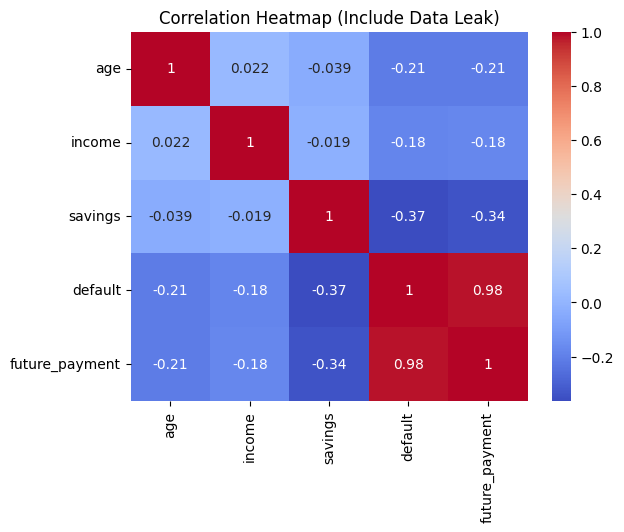

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Include Data Leak)")
plt.show()

### 6️⃣ Analisis Feature Importance via SHAP

In [10]:
import shap

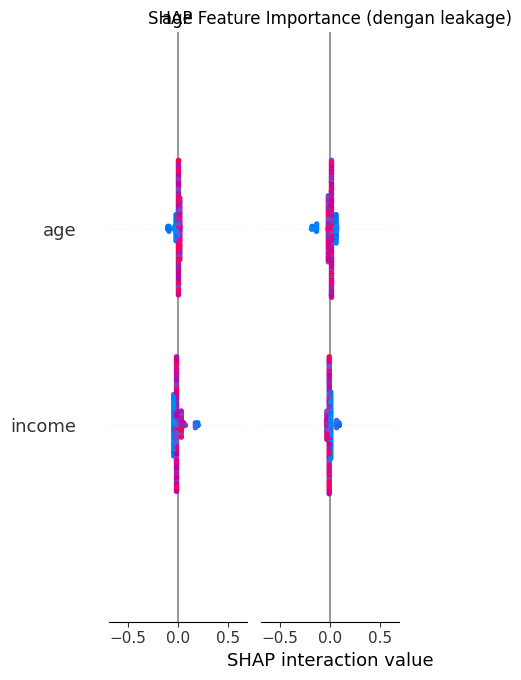

In [12]:
explainer = shap.Explainer(model_leak, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance (dengan leakage)")
plt.show()

### 7️⃣ Revise with Deleted Leakge Feature

In [13]:
X_no_leak = df.drop(columns=['default', 'future_payment'])
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_leak, y, test_size=0.3, random_state=42)

In [14]:
model_clean = RandomForestClassifier(random_state=42)
model_clean.fit(X_train2, y_train2)

RandomForestClassifier(random_state=42)

In [15]:
train_pred2 = model_clean.predict(X_train2)
test_pred2 = model_clean.predict(X_test2)

In [16]:
print("\n✅ MODEL TANPA DATA LEAKAGE")
print("Train Accuracy :", accuracy_score(y_train2, train_pred2))
print("Test Accuracy  :", accuracy_score(y_test2, test_pred2))


✅ MODEL TANPA DATA LEAKAGE
Train Accuracy : 1.0
Test Accuracy  : 1.0


💡 Penjelasan Output:
- Bagian 4 → Akurasi training & test akan sangat tinggi (mendekati 1.0) karena fitur bocor “memberitahu” target ke model.
- Bagian 5 (korelasi) → Kolom future_payment akan punya korelasi sangat tinggi dengan default, misalnya > 0.9.
- Bagian 6 (SHAP) → Plot SHAP menunjukkan future_payment menjadi fitur paling berpengaruh.
- Bagian 7 → Setelah fitur bocor dihapus, akurasi test menurun ke level wajar (~0.7–0.8), menandakan model lebih realistis.